# Data Cleaning - Income Census Dataset

In [1]:
# import required libraries
import pandas as pd
import numpy as np

In [2]:
# load the train and test dataset and combine both.
# dataset path
file_path = "../income_dataset/"

# declare the column names test and train files dont have headers.
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

# load the data
df_train = pd.read_csv(file_path + "adult.data", header=None, names=columns, sep=",",skipinitialspace=True)
df_test = pd.read_csv(file_path + "adult.test", header=None, names=columns, sep=",", skipinitialspace=True, skiprows=1)

# concatenate both datasets
df_train_test = pd.concat([df_train,df_test],axis = 0 , ignore_index=True)

In [3]:
df_train_test.sample(1)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
8695,23,Private,38251,HS-grad,9,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K


In [4]:
# standardize the income caegories

df_train_test['income'] = (df_train_test['income'].str.strip().str.replace('.','',regex=False))

In [5]:
df_train_test[['capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   capital_gain    48842 non-null  int64 
 1   capital_loss    48842 non-null  int64 
 2   hours_per_week  48842 non-null  int64 
 3   native_country  48842 non-null  object
 4   income          48842 non-null  object
dtypes: int64(3), object(2)
memory usage: 1.9+ MB


In [6]:
df_train_test[['capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']].describe(include='all')

,capital_gain,capital_loss,hours_per_week,native_country,income
count,48842.000000,48842.000000,48842.000000,48842,48842
unique,NaN,NaN,NaN,42,2
top,NaN,NaN,NaN,United-States,<=50K
freq,NaN,NaN,NaN,43832,37155
mean,1079.067626,87.502314,40.422382,NaN,NaN
std,7452.019058,403.004552,12.391444,NaN,NaN
min,0.000000,0.000000,1.000000,NaN,NaN
25%,0.000000,0.000000,40.000000,NaN,NaN
50%,0.000000,0.000000,40.000000,NaN,NaN
75%,0.000000,0.000000,45.000000,NaN,NaN


## Understand and Cleaning Steps for capital_gain

In [7]:
# check for null or missing values. considering  0 is no investment
print(df_train_test['capital_gain'].isnull().sum())

0


In [8]:
# check no of 0 and non-zero values. 91.7% people have capital_gain = 0 
print((df_train_test['capital_gain'] == 0).sum())
print((df_train_test['capital_gain'] > 0).sum())

44807
4035


Q1: 3411.0
Q3: 13550.0
IQR: 10139.0
Lower bound: -11797.5
Upper bound: 28758.5
Number of outliers: 253


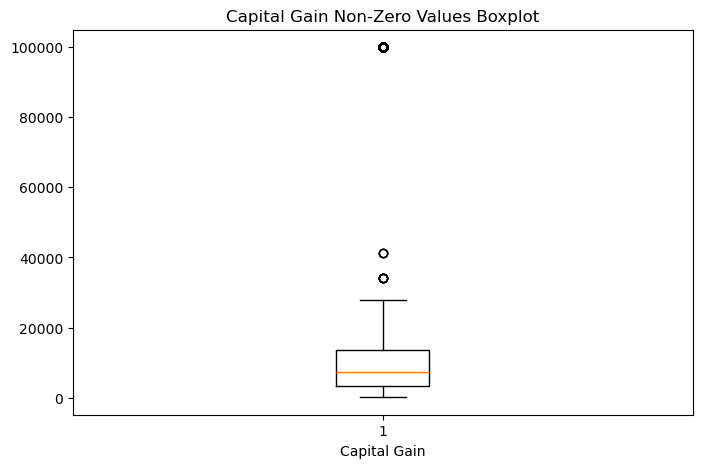

In [9]:
# Select non-zero capital_gain
capital_gain_non_zero = df_train_test[df_train_test['capital_gain'] > 0]['capital_gain']

# Q1 (25th percentile): value below which 25% of non-zero values fall
# Q3 (75th percentile): value below which 75% of non-zero values fall

Q1 = capital_gain_non_zero.quantile(0.25)
Q3 = capital_gain_non_zero.quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)
IQR = Q3 - Q1
print("IQR:", IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = capital_gain_non_zero[(capital_gain_non_zero < lower_bound) | (capital_gain_non_zero > upper_bound)]
print("Number of outliers:", len(outliers))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(capital_gain_non_zero, vert=True)
plt.title("Capital Gain Non-Zero Values Boxplot")
plt.xlabel("Capital Gain")
plt.show()


In [10]:
print(capital_gain_non_zero)

0         2174
8        14084
9         5178
59        5013
60        2407
         ...  
48805     5178
48812     2936
48813     7688
48822    15024
48840     5455
Name: capital_gain, Length: 4035, dtype: int64


In [11]:
# Filter outliers
#outliers = capital_gain_non_zero[capital_gain_non_zero > 28758.5]
outliers = capital_gain_non_zero[capital_gain_non_zero == 99999]

# Show all outlier values
print(outliers.count())


244


In [12]:
# Count outliers greater than upper bound but less than 99999
outliers_excl_max = capital_gain_non_zero[
    (capital_gain_non_zero > 28758.5) & (capital_gain_non_zero < 99999)
]

# Number of such outliers
print("Number of outliers > 28758.5 but < 99999:", len(outliers_excl_max))

# Optional: show these outlier values
print(outliers_excl_max.sort_values(ascending=False))


Number of outliers > 28758.5 but < 99999: 9
6433     41310
20176    41310
36166    41310
106      34095
4568     34095
7186     34095
15376    34095
17039    34095
36948    34095
Name: capital_gain, dtype: int64


In [13]:
df_train_test[df_train_test['capital_gain'] == 99999]['income'].value_counts()

income
>50K    244
Name: count, dtype: int64

In [14]:
# capital gain rows has 92 % values as 0 and out of 253 non-zero rows, 244 rows has the data as 99999. 
# assuming 99999 is a capped value for higher gain. we are creating a new binary column for capital_gain 0 and 1.
df_train_test['capital_gain_bin'] = (df_train_test['capital_gain'] > 0).astype(int)


In [15]:
df_train_test.head(1)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_bin
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,1


# Capital Loss column Data cleaning

In [16]:
df_train_test['capital_loss'].describe()

count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital_loss, dtype: float64

In [17]:
df_train_test['capital_loss'].value_counts().head(10)

capital_loss
0       46560
1902      304
1977      253
1887      233
2415       72
1485       71
1848       67
1590       62
1602       62
1876       59
Name: count, dtype: int64

Lower bound: 1214.5
Upper bound: 2434.5
capital_loss - Number of outliers: 46715


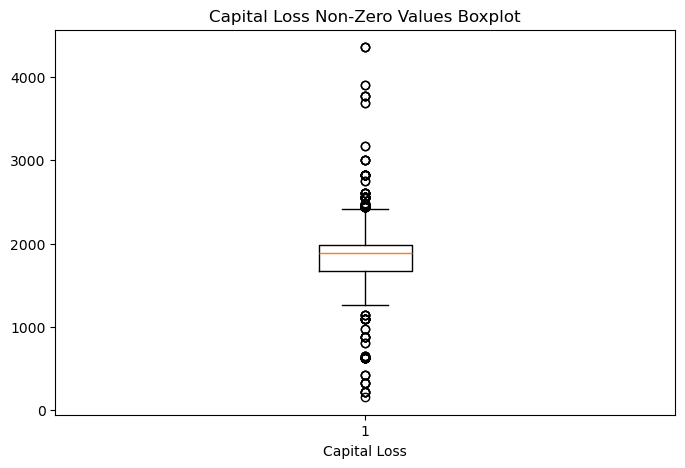

In [80]:
# Outlier detection and treatment for capital_loss using IQR

capital_loss_non_zero = df_train_test[df_train_test['capital_loss'] > 0]['capital_loss']

Q1 = capital_loss_non_zero.quantile(0.25)
Q3 = capital_loss_non_zero.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Detect outliers
outliers_loss = df_train_test[(df_train_test['capital_loss'] < lower_bound) | (df_train_test['capital_loss'] > upper_bound)]
print(f"{'capital_loss'} - Number of outliers: {outliers_loss.shape[0]}")

# Optional: Cap outliers to the bounds
#df_train_test[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

#print(f"Outlier detection and capping done for {'capital_loss'}.")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(capital_loss_non_zero, vert=True)
plt.title("Capital Loss Non-Zero Values Boxplot")
plt.xlabel("Capital Loss")
plt.show()

### Non-zero capital loss values are right-skewed, with more extreme values on the higher end. IQR method detected outliers, but these values are valid and not capped.

In [18]:
# creatign the binary column for capital loss
df_train_test['capital_loss_bin'] = (df_train_test['capital_loss'] > 0).astype(int)

In [19]:
# create new column net_capital
df_train_test['net_capital'] = df_train_test['capital_gain'] - df_train_test['capital_loss']


In [39]:
# Shows the proportion of income categories within each capital_loss_bin(0,1).
# For bin 0, most people earn <=50K. For bin 1, income is almost evenly split.

df_train_test.groupby('capital_loss_bin')['income'].value_counts(normalize=True)


capital_loss_bin  income
0                 <=50K     0.773561
                  >50K      0.226439
1                 >50K      0.501315
                  <=50K     0.498685
Name: proportion, dtype: float64

# Hours Per Week data cleaning

In [30]:
df_train_test['hours_per_week'].isnull().sum()

0

In [28]:
df_train_test['hours_per_week'].sort_values().unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87,
       88, 89, 90, 91, 92, 94, 95, 96, 97, 98, 99], dtype=int64)

In [21]:
df_train_test['hours_per_week'].describe()

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours_per_week, dtype: float64

In [22]:
df_train_test['hours_per_week'].value_counts().head(10)

hours_per_week
40    22803
50     4246
45     2717
60     2177
35     1937
20     1862
30     1700
55     1051
25      958
48      770
Name: count, dtype: int64

In [44]:
df_train_test[df_train_test['hours_per_week'] > 60].shape[0]

1676

In [40]:
df_train_test['hours_per_week'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: hours_per_week
Non-Null Count  Dtype
--------------  -----
48842 non-null  int64
dtypes: int64(1)
memory usage: 381.7 KB


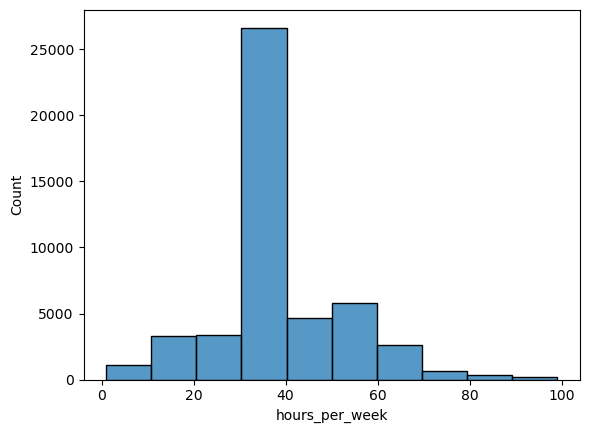

In [41]:
# check data distribution
import seaborn as sns

sns.histplot(df_train_test['hours_per_week'], bins=10)
plt.show()

### Most people work around 40 hours per week, with a few unusually high values — the maximum is 99 hours, which could be possible for extended work schedules.


In [45]:
# feature engineering
df_train_test['hours_category'] = pd.cut(
    df_train_test['hours_per_week'],
    bins=[0, 25, 40, 60, 100],
    labels=['Part-time', 'Full-time', 'Overtime', 'Extreme']
)

In [49]:
df_train_test[df_train_test['hours_per_week'] == 100]


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_bin,capital_loss_bin,net_capital,hours_category


# Native Country cleaning

In [53]:
df_train_test['native_country'].describe()

count             48842
unique               42
top       United-States
freq              43832
Name: native_country, dtype: object

In [82]:
df_train_test['native_country'].value_counts()

native_country
United-States                 43832
Mexico                          951
Unknown                         857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

In [68]:
# checck for any null values
df_train_test['native_country'].isnull().sum()

0

In [70]:
# replace '?' with nan. This will conside nan as missing or null values. we can do our missing value analysis until we repalce nan with unknown.
df_train_test['native_country'] = df_train_test['native_country'].replace('?',np.nan)

In [67]:
#df_train_test['native_country'] = df_train_test['native_country'].replace(np.nan,'?')

In [71]:
df_train_test['native_country'].isnull().sum()

857

In [72]:
df_train_test['native_country'] = df_train_test['native_country'].fillna('Unknown')

In [76]:
df_train_test['native_country'].unique()[:10]

array(['United-States', 'Cuba', 'Jamaica', 'India', 'Unknown', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England'], dtype=object)

In [78]:
df_train_test['native_country'] = df_train_test['native_country'].str.strip()  # optional, remove leading/trailing spaces

### Missing values represented by "?" were replaced with "Unknown". All other country names are valid, and no further modifications were applied

## Income

In [84]:
# Check unique values after cleaning
print(df_train_test['income'].unique())

['<=50K' '>50K']


In [ ]:
# standardize the income caegories
df_train_test['income'] = (df_train_test['income'].str.strip().str.replace('.','',regex=False))

In [85]:
# Convert income to binary for modelling as Most ML models (logistic regression, random forest, XGBoost..) 
# require a numerical target for classification
df_train_test['income_binary'] = df_train_test['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Check the result
df_train_test['income_binary'].value_counts()


income_binary
0    37155
1    11687
Name: count, dtype: int64

### The income column had inconsistent categories (e.g., >50K, >50K., <50K, <50K.). These were standardized to two consistent labels: >50K and <50K. A binary column income_binary was created for modeling, with 1 representing >50K and 0 representing <=50K.

<span style="color: blue; font-size : 20px;"><b> Data Cleaning Summary </b></span>

<span style="color: blue;"><b>Capital Gain: </b></span>
- Outliers detected using IQR method. Non-zero values are right-skewed , but values are valid and not modified
- Created binary column capital_gain_bin (1 if >0, else 0).

<span style="color: blue;"><b>Capital Loss: </b></span>
- Outliers detected using IQR method, Non-zero values are right-skewed; but values are valid and not modified
- Created binary column capital_gain_bin (1 if >0, else 0).
- New column created as net_capital = capital_gain - capital_loss.

<span style="color: blue;"><b>Hours Per Week: </b></span>
- Distribution visualized with histogram, Most people work around 40 hours per week
- A few unusually high values (>80 hours, max 99) are valid and not modified

<span style="color: blue;"><b>Native Country: </b></span>
- Missing values ("?") replaced with "Unknown".
- All other country names are valid

<span style="color: blue;"><b>Income: </b></span>
- Inconsistent categories (>50K, >50K., <50K, <50K.) were standardized to >50K and <50K
- Created binary column income_binary for modeling: 1 = >50K, 0 = <=50K


<span style="color: blue;"><b>Conclusion: </b></span>
All required columns have been cleaned and are ready for feature engineering, including encoding, grouping, and transformations. 
Outliers are  identified and only valid data is retained.
